## Muhammad Sikandar Hussain 502808

## Lab 01: Machine Learning as a Foundation for Big Data Analytics

## Activity #1. 
Worked Example: Classifying Iris Flowers (2 marks)
The Iris dataset contains 150 flowers. Four measurements describe each flower, and the species column gives the correct class. We will use these measurements to predict the species of flowers that the model has not seen during training.


Step 1: Load the file and understand its structure

Upload iris_sample.csv to Colab, then run the following cell. The purpose of this step is to confirm that the correct file has been loaded and to identify the columns before any modelling begins.


In [2]:
import pandas as pd

iris = pd.read_csv('D:\\code\\BigDataAnalytics\\lab1\\iris_sample.csv')

print('Shape:', iris.shape)
print(iris.head())
print(iris.dtypes)


Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


Step 2: Explore the data before modelling

A quick inspection helps us spot missing data and understand whether one class is much larger than the others. We will also draw a scatter plot to see whether two flower measurements help separate the species.


Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


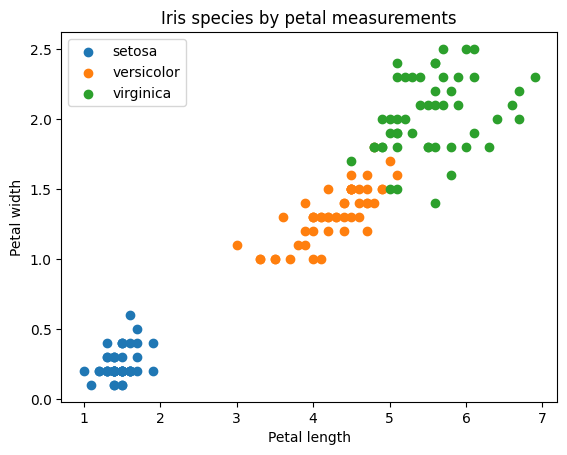

In [3]:
import matplotlib.pyplot as plt

print('Missing values:')
print(iris.isna().sum())

print('Class counts:')
print(iris['species'].value_counts())

for name, group in iris.groupby('species'):
    plt.scatter(group['petal_length'], group['petal_width'], label=name)

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('Iris species by petal measurements')
plt.legend()
plt.show()


Step 3: Prepare the data and train the model

The model must be tested on rows that were not used for learning. We therefore keep 20 percent of the data as a test set. Scaling and Logistic Regression are placed in one pipeline so that the 


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = iris.drop(columns='species')
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))


Training rows: 120
Testing rows: 30


Step 4: Test the model and inspect its mistakes

Accuracy gives the overall result, but the classification report and confusion matrix show how the model performs for each species. We will also display any test rows that were classified incorrectly.


Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



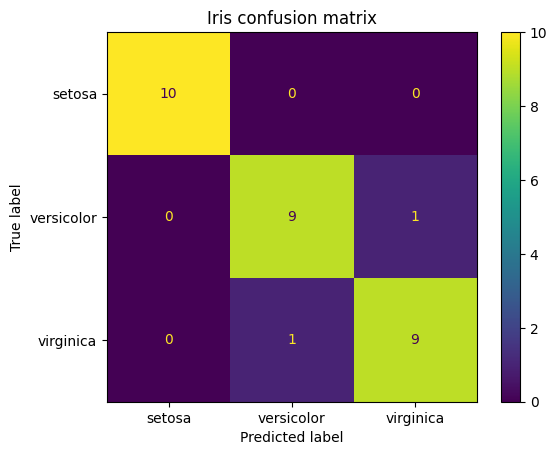

     sepal_length  sepal_width  petal_length  petal_width      actual  \
134           6.1          2.6           5.6          1.4   virginica   
77            6.7          3.0           5.0          1.7  versicolor   

      predicted  
134  versicolor  
77    virginica  


In [5]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

predicted = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, predicted))
print(classification_report(y_test, predicted))

ConfusionMatrixDisplay.from_predictions(y_test, predicted)
plt.title('Iris confusion matrix')
plt.show()

check = X_test.copy()
check['actual'] = y_test
check['predicted'] = predicted
print(check[check['actual'] != check['predicted']])


## Activity #2. Independent Task: Predicting Bank Subscriptions

Task 1: Understand the dataset 

In [6]:
import pandas as pd
bank = pd.read_csv('D:\\code\\BigDataAnalytics\\lab1\\bank-full.csv', sep=';')
print('Shape:', bank.shape)


Shape: (45211, 17)


In [7]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
bank.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [9]:
target = 'y'

numerical_columns = bank.drop(columns=target).select_dtypes(
    include='number'
).columns.tolist()

categorical_columns = bank.drop(columns=target).select_dtypes(
    exclude='number'
).columns.tolist()

print('Target:', target)
print('Numerical columns:', numerical_columns)
print('Categorical columns:', categorical_columns)

Target: y
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


Task 2: Investigate data quality and class balance 

In [10]:
duplicate_count = bank.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


In [11]:
unknown_counts = (bank.astype(str) == 'unknown').sum()

print('Unknown values in each column:')
print(unknown_counts)

Unknown values in each column:
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64


In [12]:
target_summary = pd.DataFrame({
    'count': bank['y'].value_counts(),
    'percentage': bank['y'].value_counts(normalize=True) * 100
})

print(target_summary)

     count  percentage
y                     
no   39922    88.30152
yes   5289    11.69848


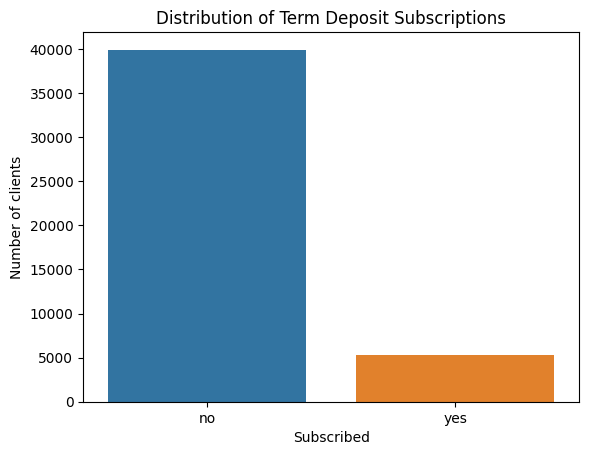

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=bank, x='y', hue='y', legend=False)
plt.title('Distribution of Term Deposit Subscriptions')
plt.xlabel('Subscribed')
plt.ylabel('Number of clients')
plt.show()

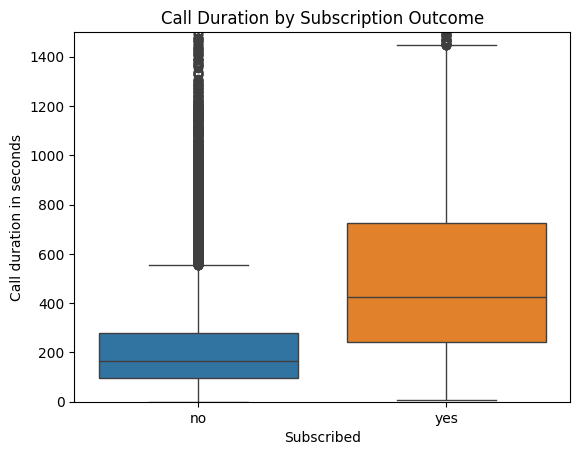

In [14]:
sns.boxplot(data=bank, x='y', y='duration', hue='y', legend=False)
plt.title('Call Duration by Subscription Outcome')
plt.xlabel('Subscribed')
plt.ylabel('Call duration in seconds')
plt.ylim(0, 1500)
plt.show()

Task 3: Build the preprocessing and model pipeline

In [15]:
from sklearn.model_selection import train_test_split

X = bank.drop(columns='y')
y = bank['y'].map({'no': 0, 'yes': 1})

numerical_columns = X.select_dtypes(include='number').columns.tolist()
categorical_columns = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Numerical columns:', numerical_columns)
print('Categorical columns:', categorical_columns)

Training rows: 36168
Testing rows: 9043
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [17]:
import time

start_time = time.perf_counter()

model.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

print(f'Training time: {training_time:.4f} seconds')

Training time: 0.6100 seconds


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred))

Accuracy:  0.9012
Precision: 0.6445
Recall:    0.3478
F1-score:  0.4518
ROC-AUC:   0.9056

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



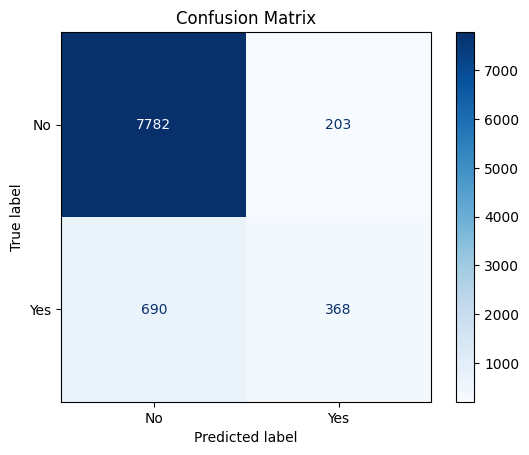

True negatives: 7782
False positives: 203
False negatives: 690
True positives: 368


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()

print('True negatives:', tn)
print('False positives:', fp)
print('False negatives:', fn)
print('True positives:', tp)

In [20]:
new_threshold = 0.30
y_pred_lower_threshold = (y_probability >= new_threshold).astype(int)

print('Results using threshold =', new_threshold)
print('Precision:', precision_score(y_test, y_pred_lower_threshold))
print('Recall:', recall_score(y_test, y_pred_lower_threshold))
print('F1-score:', f1_score(y_test, y_pred_lower_threshold))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_lower_threshold))

Results using threshold = 0.3
Precision: 0.5899795501022495
Recall: 0.5453686200378072
F1-score: 0.5667976424361493

Confusion matrix:
[[7584  401]
 [ 481  577]]


## Activity 3 — From Machine Learning to Big Data

In [21]:
import pandas as pd
import time

results = []

for copies in [1, 5, 10]:
    larger_data = pd.concat(
        [bank] * copies,
        ignore_index=True
    )

    larger_X = larger_data.drop(columns='y')

    start = time.perf_counter()
    preprocessor.fit_transform(larger_X)
    elapsed = time.perf_counter() - start

    memory_mb = (
        larger_data.memory_usage(deep=True).sum()
        / (1024 ** 2)
    )

    results.append([
        copies,
        len(larger_data),
        memory_mb,
        elapsed
    ])

scale_results = pd.DataFrame(
    results,
    columns=['copies', 'rows', 'memory_mb', 'seconds']
)

print(scale_results)

   copies    rows  memory_mb   seconds
0       1   45211   8.070874  0.497084
1       5  226055  40.353868  2.616174
2      10  452110  80.707609  4.967027
